# Idea for the Image processing pipeline

### 1. Preprocessing
* Convert to grayscale with adaptive threshold

### 2. Morphological Operations
* Erosion & Dilation: Remove small noise and preserve only long, continuous structural lines

### 3. Grid Reconstruction
* Hough Lines
  * was my first idea, but it was too clumsy
  * often produced fragmented lines or inaccurate angles due to perspective distortion in mobile photos, had to cluster (average calculation) the lines but then it didn't accurately match the actual table lines anymore

* Pixel Summation (1D Projection)
  * sum of pixels along the axes (X and Y) (dividing by 255 to get actual pixel counts)
  * Peaks in the summation curve are most likely the table lines

### 4. Intersection & Corner Detection
* Locate crossing points by finding pixels present in both the horizontal and vertical masks

### 5. Cell Extraction
* Detect closed contours within the grid

### 6. OCR
* Text Detection on the first row to detect each habit in each cell

### 7. Cross Detection
* On each cell detect if it is crossed or not
  * Ideas:
    * Black White pixel count
    * Diagonal lines

In [20]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BACKEND_PATH = Path("backend")
if str(BACKEND_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_PATH))

from app.table_detection import (
    load_image, resize_to_max, preprocess, detect_grid_lines, extract_line_positions, 
    draw_grid, detect_mark_in_cell, detect_table_pipeline, draw_marks
)
from app.table_detection import TableDetectionResult, CellResult

IMAGE_DIR = Path("tracker-table-images")

def show(img_bgr, title="", figsize=(14, 6), cmap=None):
    plt.figure(figsize=figsize)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if len(img_bgr.shape) == 3 else img_bgr, cmap="gray")
    else:
        plt.imshow(img_bgr, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1  Load sample images

In [21]:
all_images = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))
print(f"Found {len(all_images)} images:")
for p in all_images:
    print(f"  {p.name}")

Found 5 images:
  convertet.png
  example-tracker.png
  photo-edited.png
  screenshot.png
  from-web.jpg


Original size : 3888×1774
Working size  : 1800×821


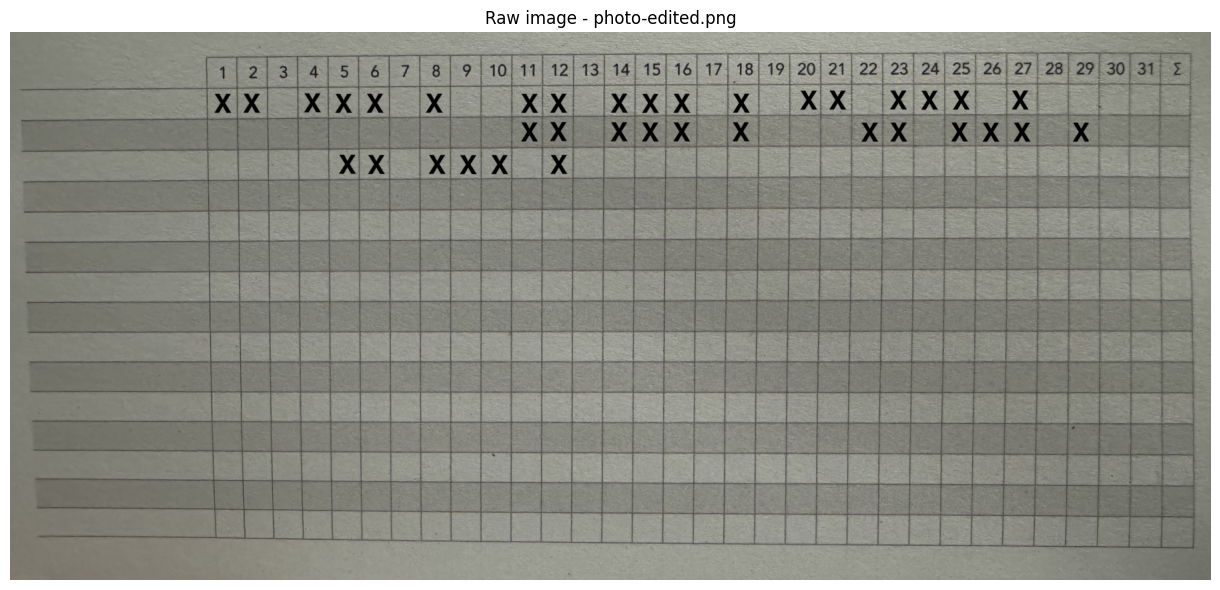

In [22]:
SAMPLE = IMAGE_DIR / "photo-edited.png"

raw = load_image(SAMPLE)
img = resize_to_max(raw, max_dim=1800)
print(f"Original size : {raw.shape[1]}×{raw.shape[0]}")
print(f"Working size  : {img.shape[1]}×{img.shape[0]}")
show(img, f"Raw image - {SAMPLE.name}")

## 2 Preprocess

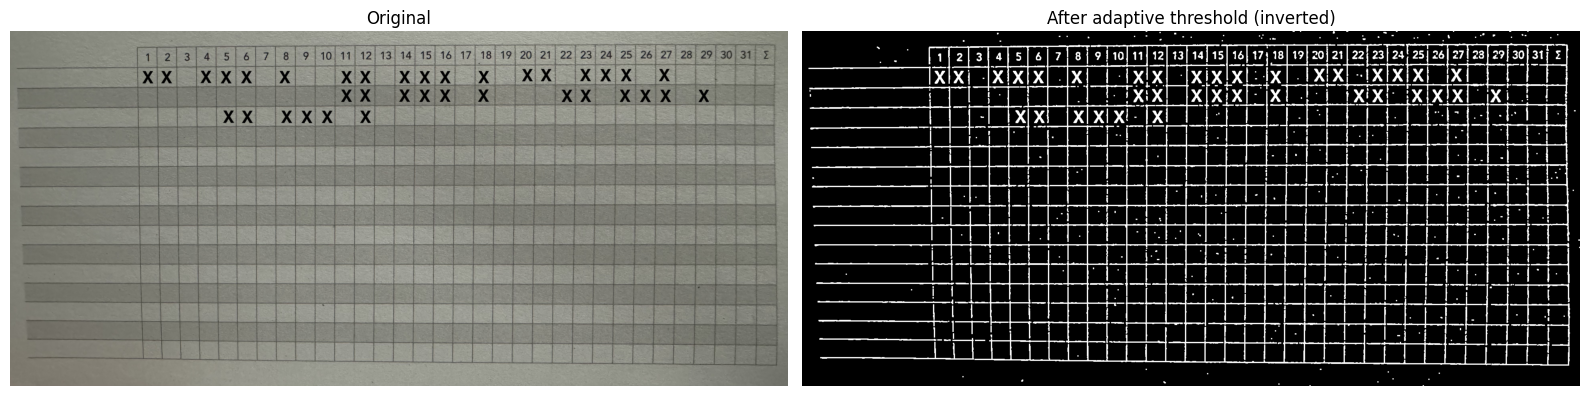

In [23]:
binary = preprocess(img)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("After adaptive threshold (inverted)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3  Grid line detection via morphology

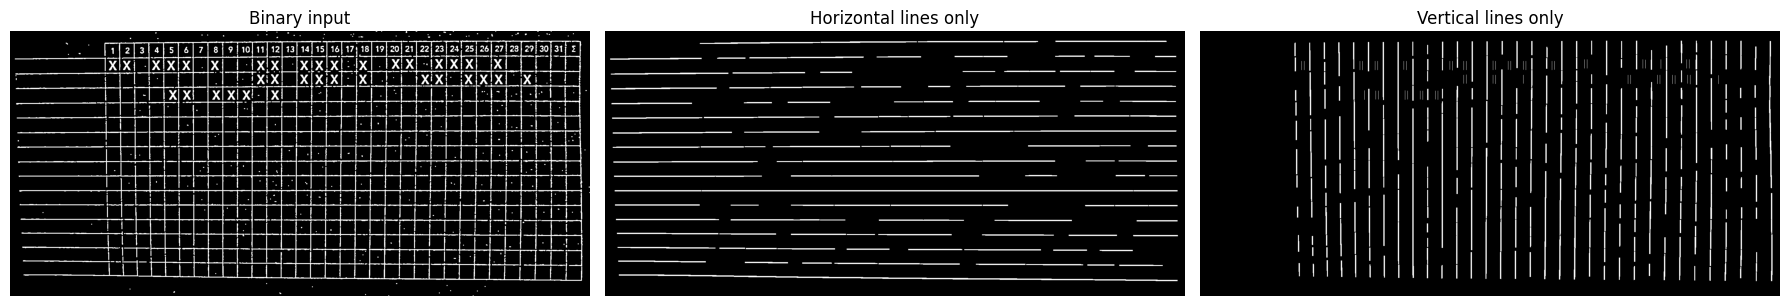

In [24]:
h_lines, v_lines = detect_grid_lines(binary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(binary, cmap="gray")
axes[0].set_title("Binary input")
axes[0].axis("off")

axes[1].imshow(h_lines, cmap="gray")
axes[1].set_title("Horizontal lines only")
axes[1].axis("off")

axes[2].imshow(v_lines, cmap="gray")
axes[2].set_title("Vertical lines only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4  Extract lines on each axis

Horizontal lines (rows): 17  → 16 cell rows
Vertical lines (cols):   33 → 32 cell columns

Row y-positions: [33, 81, 127, 172, 218, 265, 311, 357, 403, 448, 494, 539, 585, 630, 675, 722, 768]
Col x-positions: [299, 343, 389, 434, 479, 524, 570, 615, 660, 706, 751, 797, 843, 889, 935, 981, 1027, 1073, 1119, 1166, 1212, 1258, 1307, 1351, 1398, 1447, 1493, 1540, 1586, 1632, 1679, 1725, 1771]


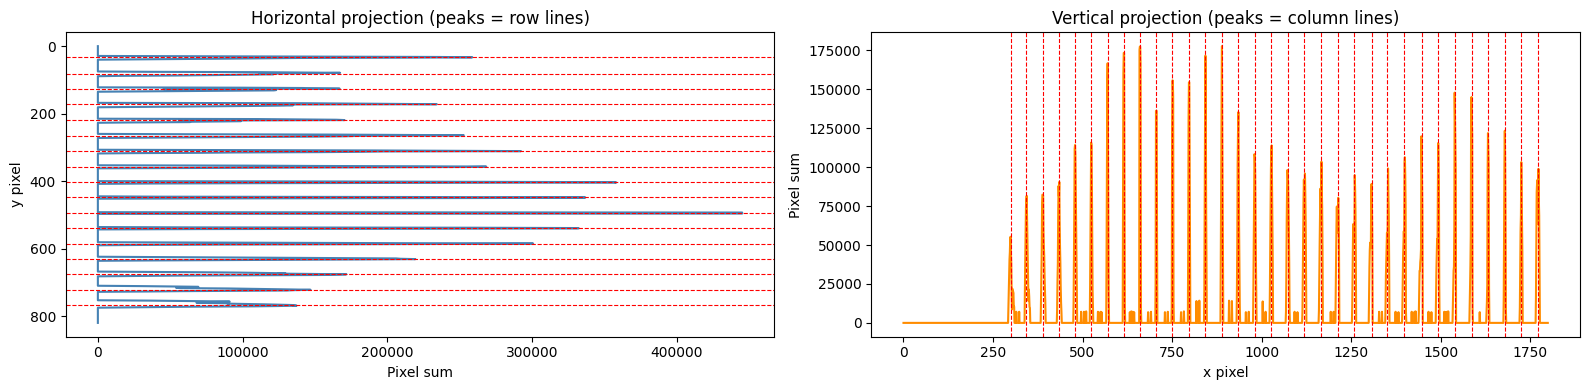

In [25]:
row_positions = extract_line_positions(h_lines, axis=1, min_gap=10)
col_positions = extract_line_positions(v_lines, axis=0, min_gap=8)

print(f"Horizontal lines (rows): {len(row_positions)}  → {len(row_positions)-1} cell rows")
print(f"Vertical lines (cols):   {len(col_positions)} → {len(col_positions)-1} cell columns")
print("\nRow y-positions:", row_positions)
print("Col x-positions:", col_positions)


h_proj = h_lines.sum(axis=1).astype(float)
v_proj = v_lines.sum(axis=0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(h_proj, range(len(h_proj)), color="steelblue")
axes[0].invert_yaxis()
for y in row_positions:
    axes[0].axhline(y=y, color="red", linewidth=0.8, linestyle="--")
axes[0].set_title("Horizontal projection (peaks = row lines)")
axes[0].set_xlabel("Pixel sum")
axes[0].set_ylabel("y pixel")

axes[1].plot(v_proj, color="darkorange")
for x in col_positions:
    axes[1].axvline(x=x, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Vertical projection (peaks = column lines)")
axes[1].set_xlabel("x pixel")
axes[1].set_ylabel("Pixel sum")

plt.tight_layout()
plt.show()

## 5  Visualise the detected grid

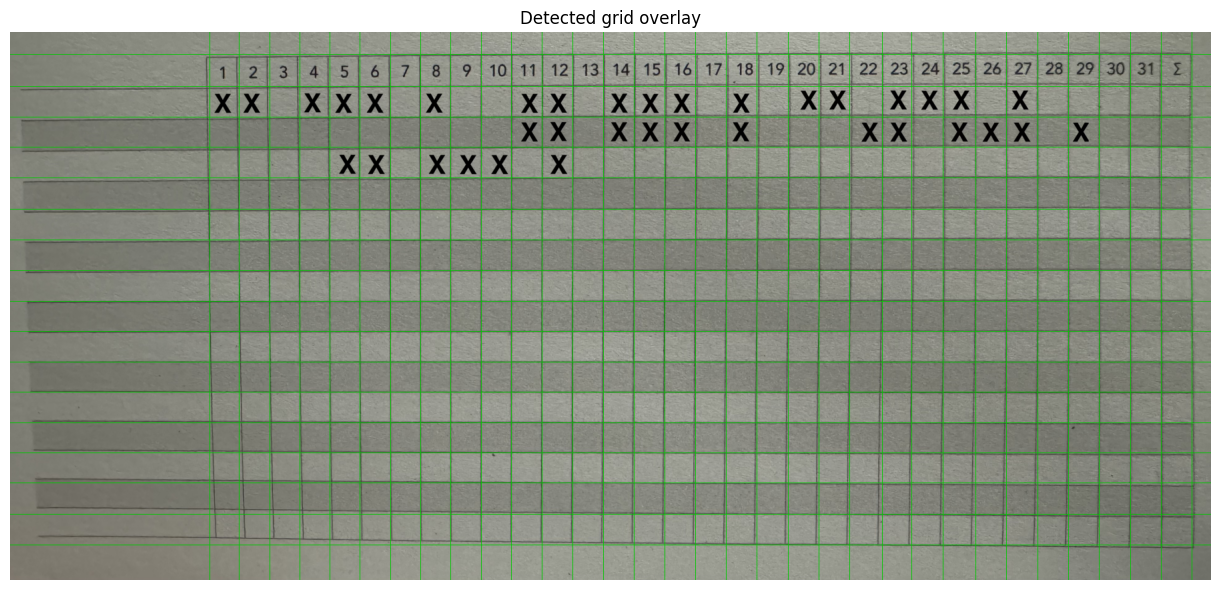

In [26]:
tableDetectionResult = TableDetectionResult(
    success=True, 
    n_rows=0, 
    n_cols=0,
    row_positions=row_positions, 
    col_positions=col_positions,
    cells=[], habit_names=[],
)
grid_img = draw_grid(img, tableDetectionResult, color=(0, 200, 0))
show(grid_img, "Detected grid overlay")

## 6 Extract individual cells

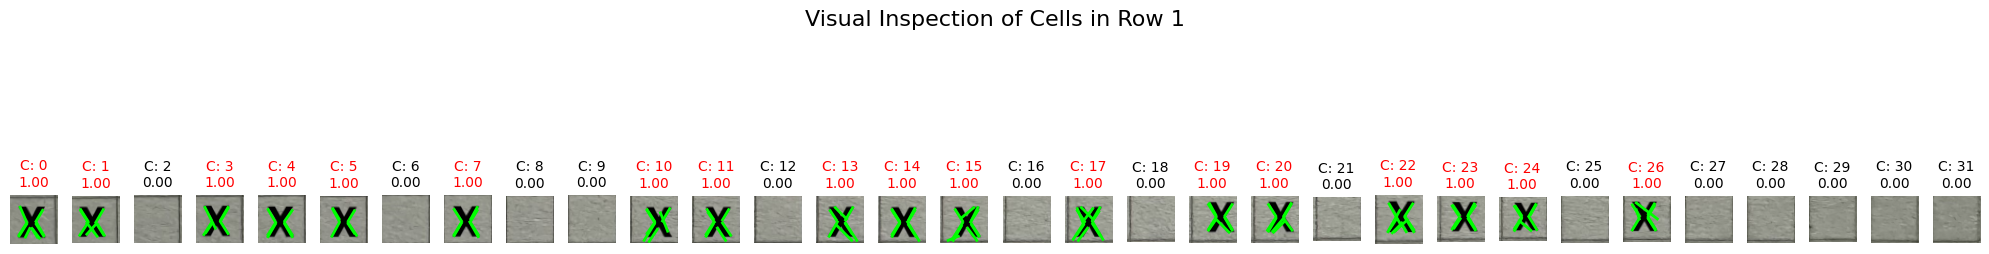

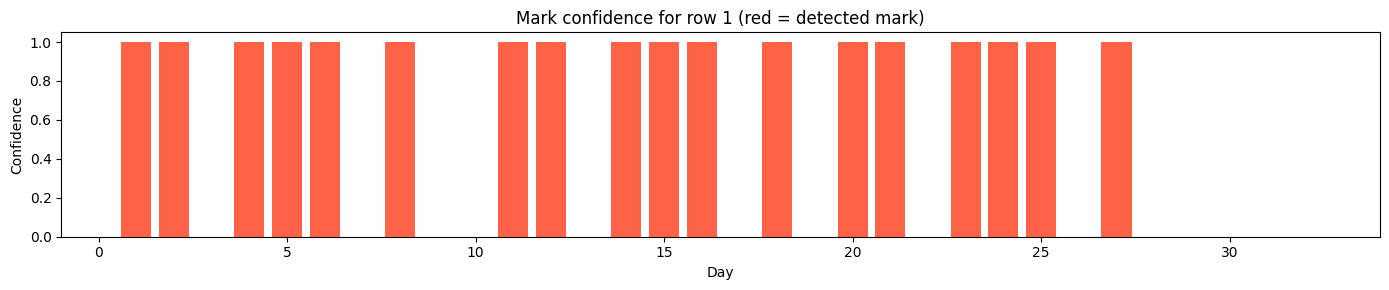

In [27]:
SAMPLE_ROW = 1
y1, y2 = row_positions[SAMPLE_ROW], row_positions[SAMPLE_ROW + 1]
n_cols = len(col_positions) - 1

fig, axes = plt.subplots(1, n_cols, figsize=(20, 4))
fig.suptitle(f"Visual Inspection of Cells in Row {SAMPLE_ROW}", fontsize=16)

densities = []
for c in range(n_cols):
    x1, x2 = col_positions[c], col_positions[c + 1]
    cell = img[y1:y2, x1:x2]
    cell_rgb = cv2.cvtColor(cell, cv2.COLOR_BGR2RGB)
        
    has_mark, conf, lines = detect_mark_in_cell(cell_rgb)
    densities.append(conf)
    
    ax = axes[c]
    ax.imshow(cell_rgb)
    
    for lx1, ly1, lx2, ly2 in lines:
        ax.plot([lx1, lx2], [ly1, ly2], color='lime', linewidth=2)
    
    title_color = "red" if has_mark else "black"
    ax.set_title(f"C: {c}\n{conf:.2f}", color=title_color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 3))
days = range(1, len(densities) + 1)
colors = ["tomato" if d > 0.2 else "steelblue" for d in densities]
plt.bar(days, densities, color=colors)
plt.xlabel("Day")
plt.ylabel("Confidence")
plt.title(f"Mark confidence for row {SAMPLE_ROW} (red = detected mark)")
plt.tight_layout()
plt.show()

## Pipeline on all images

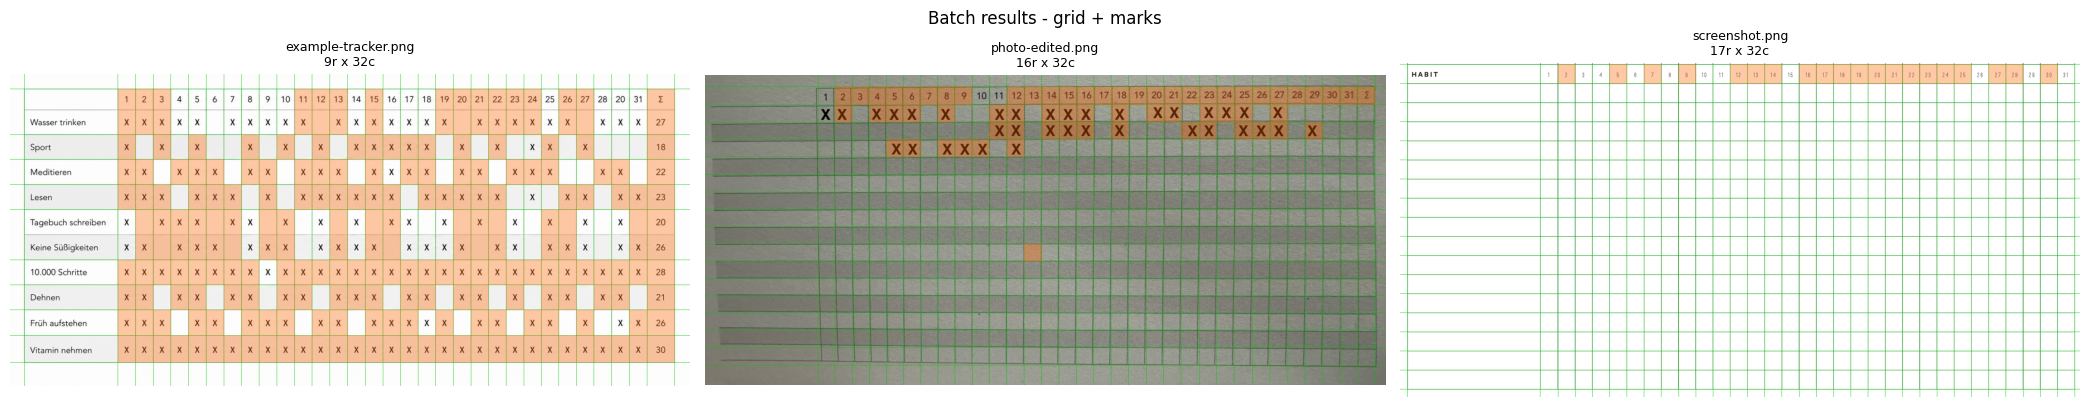

In [ ]:
successes = [p for p in all_images if p.name != "convertet.png" and detect_table_pipeline(p).success]

if successes:
    n = len(successes)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 4))
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    for ax, path in zip(axes, successes):
        res = detect_table_pipeline(path)
        raw_img = resize_to_max(load_image(path), 1800)
        vis = draw_marks(draw_grid(raw_img, res), res)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{path.name}\n{res.n_rows}r x {res.n_cols}c", fontsize=9)
        ax.axis("off")

    for ax in axes[len(successes):]:
        ax.axis("off")

    plt.suptitle("Batch results - grid + marks", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()